# OccPy tutorial notebook for Mobile Laser Scanning (MLS) data

This notebook gives a brief overview over MLS occlusion mapping using OccPy.  

The data used for this analysis were acquired using a GeoSLAM ZebHorizon handheld MLS in the Rameren forest close to the WSL in Birmensdorf, Switzerland. The forest plot is characterized as a mixed temperate forest and the data was acquired under leaf-on conditions. The data has been heavily filtered to reduce storage needs and reduce processing time. The tutorial data is the same as used for the manuscript currently under revision in RSE and available as pre-print here: https://doi.org/10.31223/X5N16X

First, we download the test data and configure paths

In [1]:
import json
import os
import shutil
from pathlib import Path

import pooch
from occpy.OccPy import OccPy

RIEGL RDBlib is not available
RIEGL RiVlib is not available
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Download test data once to cache and mirror it into the repository for stable relative paths
repo_root = Path('..', '..').resolve()
data_notebooks = repo_root / 'data_notebooks'
mls_data_dir = data_notebooks / 'MLS_demo'
data_notebooks.mkdir(parents=True, exist_ok=True)

p = pooch.create(
    path=pooch.os_cache('occpy_test_data_mls'),
    base_url='https://zenodo.org/records/17750604/files/',
    registry={'MLS_demo.zip': 'md5:1ed22572cd90768ea4ab9a34e9c70c62'},
)
p.fetch('MLS_demo.zip', processor=pooch.Unzip(members=['MLS_demo']), progressbar=True)

cache_data_dir = Path(p.path) / 'MLS_demo.zip.unzip' / 'MLS_demo'
if not mls_data_dir.exists():
    shutil.copytree(cache_data_dir, mls_data_dir)

print(f'Repository notebook data folder: {mls_data_dir}')
config_file = str(repo_root / 'config' / 'settings_MLS_tutorial.JSON')

Repository notebook data folder: C:\Users\Kueken\dev\occpy_dev\OccPy\data_notebooks\MLS_demo


OccPy configurations are saved in JSON files.

For mobile acquisitions, it is important to set is_mobile to True.

There are a few minimal requirements for a run:
- laz_in: input laz file or directory containing laz files. If given multiple las files, will assume multi-position TLS. If given single las file, will assume single-position TLS unless is_mobile is set.
- plot_dim: grid for occlusion mapping: [minX, minY, minZ, maxX, maxY, maxZ]  
- vox_dim: voxel size - currently this applies to x, y, and z dimension. Non-cubic voxels are on the list of features to be added

Optional arguments:  
- is_mobile: whether the acquisition is mobile (MLS/ULS) or static (TLS) (default: False)
- single_return: whether the data is single return or multi return data (default: False)
- out_dir: output directory (default: ./output)
- verbose: set logging level  (default: False)
- debug: set logging level (default: False)
- lower_threshold: lower threshold above ground to exclude from occlusion mapping in voxels (default: 0)
- points_per_iter: number of points read in from laz file in each iteration (default: 10000000)
- delimiter: csv delimiter for scan position file (default: ",")
- root_folder: if given, will assume other paths are relative to this root folder and will prepend it to the paths (default: None)
- str_idxs_ScanPosID: string indices of where the scan position identifier is written in the laz file name. If not given, will use file name as ID (without extension) (default: None)
- output_voxels: whether to export .ply voxel grids (large files, slow) (default: False)

Additionally, we use the config file to save paths to other files, such as the positions file, DSM and DTM.

In [3]:
# Load config and resolve all relative paths once for downstream plotting/normalization calls
with open(config_file, 'r') as file:
    config = json.load(file)

config

{'root_folder': '../..',
 'laz_in': 'data_notebooks/MLS_demo/LAZ/MLS_TestData_20perc_FP10_2025.laz',
 'tif_in': {'DTM': 'data_notebooks/MLS_demo/Grids/Ramerenwald_DTM_20250305.tif',
  'DSM': 'data_notebooks/MLS_demo/Grids/Ramerenwald_DSM_20250305.tif'},
 'out_dir': 'output/MLS',
 'vox_dim': 0.1,
 'lower_threshold': 1,
 'points_per_iter': 1000000,
 'plot_dim': [2676515, 1246063, 545, 2676525, 1246113, 590],
 'ScanPos': 'data_notebooks/MLS_demo/ScanPos/MLS_TestData_traj_FP10_2025.txt',
 'output_voxels': False,
 'single_return': True,
 'is_mobile': True}

### Running OccPy

First step is to create an OccPy object with the config file.

In [4]:
test = OccPy(config=config)

INFO: optional arguments: ['out_dir', 'output_voxels', 'verbose', 'debug', 'lower_threshold', 'points_per_iter', 'delimiter', 'root_folder', 'single_return', 'str_idxs_ScanPosID']


Then, read in the trajectory information.

In [5]:
test.define_sensor_pos(path2file=config['ScanPos'],         # Path to the trajectory file
                       delimiter=' ',                        # Delimiter used in the trajectory file
                       hdr_time='//world_time',             # Column header for the time information
                       hdr_x='x',                           # Column header for X coordinate
                       hdr_y='y',                           # Column header for Y coordinate
                       hdr_z='z')                           # Column header for Z coordinate

Now we can start the raytracing and save the outputs.

In [6]:
import time
tic = time.time()
test.do_raytracing()
toc = time.time()
print(f"Raytracing took {toc - tic:.2f} seconds.")

Tracing Pulses...: 100%|██████████| 5680089/5680089 [00:43<00:00, 129898.02pulses/s]


b'#### 2981545 Pulses were traversed of possible 5680089 Pulses\n#### 919306 Returns have been registered by the algorithm \n#### 2062238 Returns were found outside the voxel grid \n#### 0 Returns were missed during the traversal!\n#### 2698544 Pulses did not intersect voxel grid!\n'
Raytracing took 51.30 seconds.


We can now height normalize the outputs using the provided DTM and DSM file. The DSM file is only to define the upper bounds of the canopy. Function 'normalize_occlusion_output' will also store the normalized voxel grids as npy files in the specified output folder

In [7]:
from occpy.util import normalize_occlusion_output

In [8]:
Nhit_norm, Nmiss_norm, Nocc_norm, Classification_norm, chm = normalize_occlusion_output(input_folder=os.path.join(config["root_folder"], config['out_dir']),
                                                                                        PlotDim=config['plot_dim'],
                                                                                        vox_dim=config['vox_dim'],
                                                                                        dtm_file=os.path.join(config["root_folder"], config['tif_in']['DTM']),
                                                                                        dsm_file=os.path.join(config["root_folder"], config['tif_in']['DSM']),
                                                                                        lower_threshold=config['lower_threshold'],
                                                                                        output_voxels=config['output_voxels'])

# If instead of a binary voxel grid classification, you are intereded in a fraction of occluded pulses per voxel, you can use the following function:
OcclFrac_norm = Nocc_norm.astype(float) / (Nhit_norm.astype(float) + Nmiss_norm.astype(float) + Nocc_norm.astype(float))


Saving normalized output files into directory as .npy...


C:\Users\Kueken\AppData\Local\Temp\ipykernel_17972\1866247174.py:10: RuntimeWarning: invalid value encountered in divide
  OcclFrac_norm = Nocc_norm.astype(float) / (Nhit_norm.astype(float) + Nmiss_norm.astype(float) + Nocc_norm.astype(float))


We can also visualize the results. Note that there is a lot of occlusion shown in this example. This is caused by the heavy filtering performed to reduce data size of this example dataset.

In [9]:
from occpy.visualization import get_Occl_TransectFigure_BinaryOcclusion, get_Occlusion_ProfileFigure

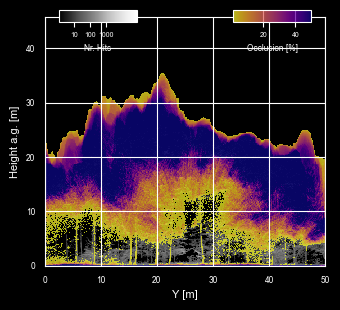

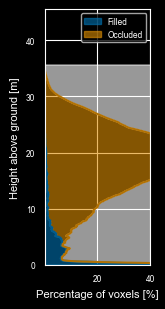

In [10]:
# first define figure properties
fig_prop = dict(fig_size=(3.5, 3.2),        # figure size in inches
                label_size=8,               # label size in pts. for e.g. axis labels
                label_size_ticks=6,         # label size in pts. for e.g. axis ticks
                label_size_tiny=5,          # label size in pts. for e.g. ticks in colorbar
                out_format='png',)          # output format of the figure, can be 'png', 'pdf', 'svg', etc.

%matplotlib inline
get_Occl_TransectFigure_BinaryOcclusion(Nhit_norm, Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'],
                                        out_dir=os.path.join(config["root_folder"], config['out_dir']), axis=0, start_ind=0, end_ind=100, vertBuffer=10, fig_prop=fig_prop, show_plots=True)

# define other figure properties for the smaller figure
fig_prop = dict(fig_size=(1.75, 3.2),
                label_size=8,
                label_size_ticks=6,
                label_size_tiny=5,
                out_format='png', )
get_Occlusion_ProfileFigure(Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'], out_dir=os.path.join(config["root_folder"], config['out_dir']), low_thresh=0, vertBuffer=10, max_percentage=40, fig_prop=fig_prop, show_plots=True)